In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

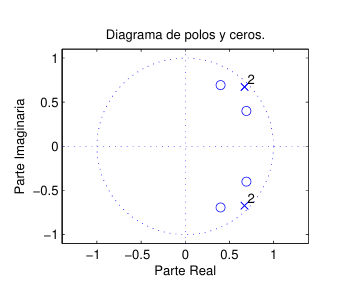

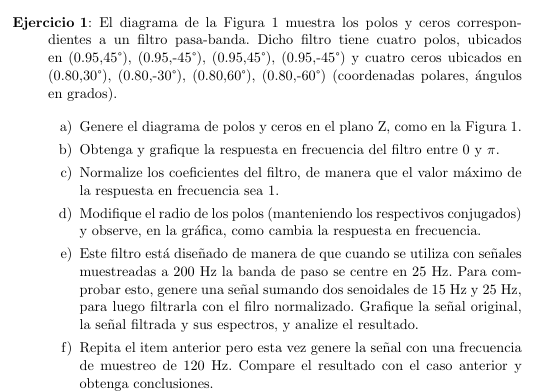

In [ ]:
frecM = 200

# Definimos Radios
r_1 = .95
r_2 = .8

#definimos Angulos
angs_1 = 45
angs_2 = 30
angs_3 = 60

# Pasamos a radianes
rads_1 = angs_1 * np.pi / 180
rads_2 = angs_2 * np.pi / 180
rads_3 = angs_3 * np.pi / 180

# Obtenemos los puntos en forma de exponencial compleja
ceros = np.array([
    r_2 * np.exp(1j * rads_2),
    r_2 * np.exp(1j * -rads_2),
    r_2 * np.exp(1j * rads_3),
    r_2 * np.exp(1j * -rads_3),
])

polos = np.array([
    r_1 * np.exp(1j * rads_1),
    r_1 * np.exp(1j * -rads_1),
    r_1 * np.exp(1j * rads_1),
    r_1 * np.exp(1j * -rads_1),
])

In [ ]:
def graficar_plano_z(ceros, polos, frecM):
    eje_real = np.linspace(-1, 1, frecM)
    eje_img = eje_real * np.tan(np.arccos(eje_real))

    plt.figure(figsize=(5,5))
    plt.title("Plano z")
    plt.plot(eje_real, eje_img, '--', c='b')
    plt.plot(eje_real, -eje_img, '--', c='b')
    plt.plot(eje_real, np.zeros_like(eje_real), c='black')
    plt.plot(np.zeros_like(eje_real), eje_real, c='black')
    plt.plot(ceros.real, ceros.imag, 'o', c='green', label='Ceros', alpha=0.3)
    plt.plot(polos.real, polos.imag, 'x', c='red', label='Polos')
    plt.xlabel("Eje real")
    plt.ylabel("Eje imaginario")
    plt.legend()
    plt.grid()
    plt.show()

graficar_plano_z(ceros, polos, frecM)

In [ ]:
def obtener_H(ceros, polos, frecM, omega_0 = None):
    # omega_0 representa la frecuencia (ángulo) donde
    # estén los polos más importantes
    
    numerador = np.poly(ceros)
    denominador = np.poly(polos)
    dom = np.linspace(0, np.pi, frecM//2)
    dom_cx = np.exp(-1j * dom)
    H_tr = np.polyval(numerador, dom_cx) / np.polyval(denominador, dom_cx)
    
    if omega_0 != None:
        z0 = np.exp(-1j * omega_0)
        k = np.abs(np.polyval(numerador, z0) / np.polyval(denominador, z0))
        H_tr = H_tr / k

    return H_tr

H_tr = obtener_H(ceros, polos, frecM, np.pi/4)
plt.figure(figsize=(8,4))
plt.title("Respuesta en frecuencia")
plt.plot(np.abs(H_tr), c='green')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("$|H(e^{j\\omega})|$")
plt.grid()
plt.show()


In [ ]:
# Probemos diferentes radios
# Definimos Radios
R = np.array([
    [0.95, 0.95], # Radios polos
    [0.85, 0.85] # Radios Ceros
])

#definimos Angulos
A = np.array([
    [45, 90], # Angulos polos
    [30, 100] # Angulos ceros
])

# Pasamos a radianes
A = A * np.pi / 180

# Obtenemos los puntos en forma de exponencial compleja
ceros_prueba = []

for i in range(len(R[1])):
    polo_i = R[1,i] * np.exp(1j * A[1,i])
    ceros_prueba.append(polo_i)
    polo_i = R[1,i] * np.exp(1j * -A[1,i])
    ceros_prueba.append(polo_i)
ceros_prueba = np.array(ceros_prueba)

polos_prueba = []
for i in range(len(R[0])):
    polo_i = R[0,i] * np.exp(1j * A[0,i])
    polos_prueba.append(polo_i)
    polo_i = R[0,i] * np.exp(1j * -A[0,i])
    polos_prueba.append(polo_i)
polos_prueba = np.array(polos_prueba)

In [ ]:
graficar_plano_z(ceros_prueba, polos_prueba, frecM)

In [ ]:
H_tr_prueba = obtener_H(ceros_prueba, polos_prueba, frecM, np.pi/4)
plt.figure(figsize=(8,4))
plt.title("Respuesta en frecuencia")
plt.plot(np.abs(H_tr_prueba), c='green')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("$|H(e^{j\\omega})|$")
plt.grid()
plt.show()


In [ ]:
def generar_senoidal(N, frecs, frecM):
    # N = n° segundos
    Tm = 1/frecM

    dom = np.arange(0, N, Tm)

    senoidal_final = np.zeros_like(dom)
    for f in range(len(frecs)):
        senoidal = np.sin(dom * 2 * np.pi * frecs[f])
        senoidal_final += senoidal
    
    
    return dom, senoidal_final

In [ ]:
duracion = 1
dom, seno_comb = generar_senoidal(duracion,[15,25],frecM)

plt.figure(figsize=(8,4))
plt.title("Sinusoidales 15 Hz + 25 HZ")
plt.plot(dom, seno_comb)
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.show()

In [ ]:
numerador = np.poly(ceros)
denominador = np.poly(polos)

seno_filtrado = signal.lfilter(numerador, denominador, seno_comb)

fft_seno_filtrado = np.fft.fft(seno_filtrado)
norm_seno_filtrado = np.abs(fft_seno_filtrado)

frecs = np.fft.fftfreq(len(norm_seno_filtrado), d=1/frecM)

frecs_shift = np.fft.fftshift(frecs)
norm_sf_shift = np.fft.fftshift(norm_seno_filtrado)

# ---

fft_seno_comb = np.fft.fft(seno_comb)
norm_fft_sf = np.abs(fft_seno_comb)
norm_fft_sf_shift = np.fft.fftshift(norm_fft_sf)

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
plt.title("Señal original")
plt.plot(dom, seno_comb)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(2,2,2)
plt.title("Espectro original")
plt.plot(frecs_shift, norm_fft_sf_shift)
plt.xlabel("Frecuencias [Hz]")

plt.subplot(2,2,3)
plt.title("Señal filtrada")
plt.plot(dom, seno_filtrado)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(2,2,4)
plt.title("Espectro")
plt.plot(frecs_shift, norm_sf_shift)
plt.xlabel("Frecuencias [Hz]")
plt.tight_layout()
plt.show()

In [ ]:
frecM = 120

duracion = 1
dom, seno_comb = generar_senoidal(duracion,[15,25],frecM)

plt.figure(figsize=(8,4))
plt.title("Sinusoidales 15 Hz + 25 HZ")
plt.plot(dom, seno_comb)
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.show()

In [ ]:
numerador = np.poly(ceros)
denominador = np.poly(polos)

seno_filtrado = signal.lfilter(numerador, denominador, seno_comb)

fft_seno_filtrado = np.fft.fft(seno_filtrado)
norm_seno_filtrado = np.abs(fft_seno_filtrado)

frecs = np.fft.fftfreq(len(norm_seno_filtrado), d=1/frecM)

frecs_shift = np.fft.fftshift(frecs)
norm_sf_shift = np.fft.fftshift(norm_seno_filtrado)

# ---

fft_seno_comb = np.fft.fft(seno_comb)
norm_fft_sf = np.abs(fft_seno_comb)
norm_fft_sf_shift = np.fft.fftshift(norm_fft_sf)

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
plt.title("Señal original")
plt.plot(dom, seno_comb)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(2,2,2)
plt.title("Espectro original")
plt.plot(frecs_shift, norm_fft_sf_shift)
plt.xlabel("Frecuencias [Hz]")

plt.subplot(2,2,3)
plt.title("Señal filtrada")
plt.plot(dom, seno_filtrado)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(2,2,4)
plt.title("Espectro")
plt.plot(frecs_shift, norm_sf_shift)
plt.xlabel("Frecuencias [Hz]")
plt.tight_layout()
plt.show()

Ejercicio 2: Dise˜ne un filtro pasa-altos de tipo Butterworth con frecuencia de
corte 500 Hz. Realice todos los pasos del proceso de dise˜no: comenzando por
el dise˜no anal´ogico, seguido por la transformaci´on en frecuencia y la transfor
maci´on conforme. Para obtener el filtro digital correspondiente, suponga que
se procesar´an se˜nales con frecuencia de muestreo 2000 Hz. Utilice diferentes
´ordenes y compare los resultados graficando las respuestas en frecuencia.

In [ ]:
Ordenes = [1, 3, 5, 15, 25, 50]

eps = 1e0
fs = 2000
w_p = 500
# Evitemos pre_warping porque somos lo que somos
w_c = 2*fs*np.tan(np.pi * w_p/fs)

plt.figure(figsize=(16,8))
for n in range(len(Ordenes)):
    # Diseño de filtro analógico normalizado
    z, p, k = signal.butter(Ordenes[n], 1, btype = 'lowpass', analog = True, output='zpk')

    # Pasamos a pasa-alto
    z2, p2, k2 = signal.lp2hp_zpk(z, p, k, wo=w_c)

    # Recuperamos transformada analógica
    ceros_coefs, polos_coefs = signal.zpk2tf(z2,p2,k2)

    # Aplicamos mapeo bilineal
    numerator, denominator = signal.bilinear(ceros_coefs, polos_coefs, fs=fs)

    # Obtenemos funcion de transferencia del filtro
    w, H = signal.freqz(numerator, denominator, fs = fs)

    plt.subplot(2,3,n+1)
    plt.plot(w, np.abs(H))
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("|H(f)|")
    plt.title(f"Respuesta en frecuencia N = {Ordenes[n]}")
    plt.grid()

plt.tight_layout()
plt.show()

Ejercicio 3: Dise˜ne un filtro pasa-banda con frecuencias de corte 2500 y 3000 Hz.
Para el dise˜no se requiere que la atenuaci´on m´axima en la banda de paso sea
de 0,7 dB y la atenuaci´on m´ınima en la banda de rechazo sea de 55 dB. Las
bandas de transici´on deben ser de 500 Hz como m´aximo y considere que la
frecuencia de muestreo de las se˜nales a procesar ser´a de 10 kHz. Compare
los resultados obtenidos para filtros de Butterworth y Chebyshev tipo I y
II, teniendo en cuenta las atenuaciones producidas en las bandas de paso
y rechazo, y el ancho de las bandas de transici´on. Compare los resultados
obtenidos para los mismos filtros pero con el menor de todos los ´ordenes
obtenidos anteriormente.

In [ ]:
gpass = 0.7
gstop = 55
eps = 800
fs = 10000
w_p1 = 2500
w_p2 = 3000
# Evitemos pre_warping porque somos lo que somos
eps_larp = 2 * fs * np.tan(np.pi * eps/fs) 
w_c1 = 2*fs*np.tan(np.pi * w_p1/fs)
w_c2 = 2*fs*np.tan(np.pi * w_p2/fs)

# Diseño de filtro analógico normalizado
# Butterworth
N_bw, wn_bw = signal.buttord([w_c1, w_c2], [w_c1 - eps_larp, w_c2 + eps_larp], gpass, gstop, analog=True)
N_bw = 10
print("Orden:",N_bw)
z_bw, p_bw, k_bw = signal.butter(N_bw, wn_bw, btype = 'bandpass', analog = True, output='zpk')

# Chebyshev Tipo I
N_cs1, wn_cs1 = signal.cheb1ord([w_c1, w_c2], [w_c1 - eps_larp, w_c2 + eps_larp], gpass, gstop, analog=True)
N_cs1 = 10
print("Orden:", N_cs1)
z_cs1, p_cs1, k_cs1 = signal.cheby1(N_cs1, rp=gpass, Wn=wn_cs1, btype = 'bandpass', analog = True, output='zpk')

# Chebyshev Tipo II
N_cs2, wn_cs2 = signal.cheb1ord([w_c1, w_c2], [w_c1 - eps_larp, w_c2 + eps_larp], gpass, gstop, analog=True)
N_cs2 = 10
print("Orden:",N_cs2)
z_cs2, p_cs2, k_cs2 = signal.cheby2(N_cs2, rs=gstop, Wn=wn_cs2, btype = 'bandpass', analog = True, output='zpk')


# Recuperamos transformada analógica
# Butterworth
ceros_coefs_bw, polos_coefs_bw = signal.zpk2tf(z_bw,p_bw,k_bw)

# Chebyshev Tipo I
ceros_coefs_cs1, polos_coefs_cs1 = signal.zpk2tf(z_cs1,p_cs1,k_cs1)

# Chebyshev Tipo II
ceros_coefs_cs2, polos_coefs_cs2 = signal.zpk2tf(z_cs2,p_cs2,k_cs2)


# Aplicamos mapeo bilineal
# Butterworth
numerator_bw, denominator_bw = signal.bilinear(ceros_coefs_bw, polos_coefs_bw, fs=fs)

# Chebyshev Tipo I
numerator_cs1, denominator_cs1 = signal.bilinear(ceros_coefs_cs1, polos_coefs_cs1, fs=fs)

# Chebyshev Tipo II
numerator_cs2, denominator_cs2 = signal.bilinear(ceros_coefs_cs2, polos_coefs_cs2, fs=fs)


# Obtenemos funcion de transferencia del filtro
# Butterworth
w_bw, H_bw = signal.freqz(numerator_bw, denominator_bw, fs = fs)

# Chebyshev Tipo I
w_cs1, H_cs1 = signal.freqz(numerator_cs1, denominator_cs1, fs = fs)

# Chebyshev Tipo II
w_cs2, H_cs2 = signal.freqz(numerator_cs2, denominator_cs2, fs = fs)

plt.figure(figsize=(12,8))
plt.subplot(3,1,1)
plt.plot(w_bw, np.abs(H_bw))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(f)|")
plt.title(f"Butterworth N = {N_bw}")
plt.grid()

plt.subplot(3,1,2)
plt.plot(w_cs1, np.abs(H_cs1))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(f)|")
plt.title(f"Chebyshev Tipo I N = {N_cs1}")
plt.grid()

plt.subplot(3,1,3)
plt.plot(w_cs2, np.abs(H_cs2))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(f)|")
plt.title(f"Chebyshev Tipo II N = {N_cs2}")
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
gpass = 0.7
gstop = 55
eps = 800
fs = 10000
w_p1 = 2500
w_p2 = 3000
# Evitemos pre_warping porque somos lo que somos
eps_larp = 2 * fs * np.tan(np.pi * eps/fs) 
w_c1 = 2*fs*np.tan(np.pi * w_p1/fs)
w_c2 = 2*fs*np.tan(np.pi * w_p2/fs)

# Diseño de filtro analógico normalizado
# Butterworth
N_bw, wn_bw = signal.buttord([w_c1, w_c2], [w_c1 - eps_larp, w_c2 + eps_larp], gpass, gstop, analog=True)
N_bw = 6
print("Orden:",N_bw)
z_bw, p_bw, k_bw = signal.butter(N_bw, wn_bw, btype = 'bandpass', analog = True, output='zpk')

# Chebyshev Tipo I
N_cs1, wn_cs1 = signal.cheb1ord([w_c1, w_c2], [w_c1 - eps_larp, w_c2 + eps_larp], gpass, gstop, analog=True)
N_cs1 = 6
print("Orden:", N_cs1)
z_cs1, p_cs1, k_cs1 = signal.cheby1(N_cs1, rp=gpass, Wn=wn_cs1, btype = 'bandpass', analog = True, output='zpk')

# Chebyshev Tipo II
N_cs2, wn_cs2 = signal.cheb1ord([w_c1, w_c2], [w_c1 - eps_larp, w_c2 + eps_larp], gpass, gstop, analog=True)
N_cs2 = 6
print("Orden:",N_cs2)
z_cs2, p_cs2, k_cs2 = signal.cheby2(N_cs2, rs=gstop, Wn=wn_cs2, btype = 'bandpass', analog = True, output='zpk')


# Recuperamos transformada analógica
# Butterworth
ceros_coefs_bw, polos_coefs_bw = signal.zpk2tf(z_bw,p_bw,k_bw)

# Chebyshev Tipo I
ceros_coefs_cs1, polos_coefs_cs1 = signal.zpk2tf(z_cs1,p_cs1,k_cs1)

# Chebyshev Tipo II
ceros_coefs_cs2, polos_coefs_cs2 = signal.zpk2tf(z_cs2,p_cs2,k_cs2)


# Aplicamos mapeo bilineal
# Butterworth
numerator_bw, denominator_bw = signal.bilinear(ceros_coefs_bw, polos_coefs_bw, fs=fs)

# Chebyshev Tipo I
numerator_cs1, denominator_cs1 = signal.bilinear(ceros_coefs_cs1, polos_coefs_cs1, fs=fs)

# Chebyshev Tipo II
numerator_cs2, denominator_cs2 = signal.bilinear(ceros_coefs_cs2, polos_coefs_cs2, fs=fs)


# Obtenemos funcion de transferencia del filtro
# Butterworth
w_bw, H_bw = signal.freqz(numerator_bw, denominator_bw, fs = fs)

# Chebyshev Tipo I
w_cs1, H_cs1 = signal.freqz(numerator_cs1, denominator_cs1, fs = fs)

# Chebyshev Tipo II
w_cs2, H_cs2 = signal.freqz(numerator_cs2, denominator_cs2, fs = fs)

plt.figure(figsize=(12,8))
plt.subplot(3,1,1)
plt.plot(w_bw, np.abs(H_bw))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(f)|")
plt.title(f"Butterworth N = {N_bw}")
plt.grid()

plt.subplot(3,1,2)
plt.plot(w_cs1, np.abs(H_cs1))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(f)|")
plt.title(f"Chebyshev Tipo I N = {N_cs1}")
plt.grid()

plt.subplot(3,1,3)
plt.plot(w_cs2, np.abs(H_cs2))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(f)|")
plt.title(f"Chebyshev Tipo II N = {N_cs2}")
plt.grid()

plt.tight_layout()
plt.show()